In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor

import json

In [2]:
df = pd.read_csv('../../data/processed/featured_lending-club-car-loan.csv')

In [3]:
df.columns

Index(['Unnamed: 0', 'int_rate', 'loan_amnt', 'term', 'installment',
       'annual_inc', 'verification_status', 'emp_length', 'revol_util',
       'revol_bal', 'total_acc', 'open_acc', 'purpose', 'target', 'fico_score',
       'credit_history_length', 'credit_score_norm', 'log_delinquency',
       'log_loan_amount', 'log_installment', 'log_income',
       'log_credit_history_length', 'log_inquiries', 'inquiries',
       'log_loan_to_income', 'log_dti'],
      dtype='object')

In [4]:
features = [
    "term",
    "fico_score",
    "log_installment",
    "log_loan_amount",
    "revol_util",
    "log_dti",
    "log_income"
]

In [5]:
df["term_x_score"] = df["term"] * df["fico_score"]
df["loan_x_score"] = df["log_loan_amount"] * df["fico_score"]

In [6]:
features += ["term_x_score", "loan_x_score"]

In [7]:
y_apr = df["int_rate"]

In [8]:
X_apr = df[features]

In [9]:
X_apr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373508 entries, 0 to 1373507
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   term             1373508 non-null  int64  
 1   fico_score       1373508 non-null  float64
 2   log_installment  1373508 non-null  float64
 3   log_loan_amount  1373508 non-null  float64
 4   revol_util       1373508 non-null  float64
 5   log_dti          1373508 non-null  float64
 6   log_income       1373508 non-null  float64
 7   term_x_score     1373508 non-null  float64
 8   loan_x_score     1373508 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 94.3 MB


In [10]:
print(X_apr.shape)

(1373508, 9)


In [11]:
print(y_apr.describe())

count    1.373508e+06
mean     1.328534e+01
std      4.787062e+00
min      5.310000e+00
25%      9.750000e+00
50%      1.279000e+01
75%      1.602000e+01
max      3.099000e+01
Name: int_rate, dtype: float64


Baseline APR Model (Linear Regression)
APR = f(borrower + loan features)


In [12]:
X_train_apr, X_test_apr, y_train_apr, y_test_apr = train_test_split(
    X_apr, y_apr,
    test_size=0.2,
    random_state=42
)

In [13]:
lr_apr = LinearRegression()
lr_apr.fit(X_train_apr, y_train_apr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred_apr = lr_apr.predict(X_test_apr)

In [15]:
rmse = np.sqrt(mean_squared_error(y_test_apr, y_pred_apr))
print("RMSE:", rmse)

RMSE: 1.3898433387587787


In [16]:
mae = mean_absolute_error(y_test_apr, y_pred_apr)
print("MAE:", mae)

MAE: 0.7189623097342716


In [17]:
r2 = r2_score(y_test_apr, y_pred_apr)
print("R2:", r2)

R2: 0.915357559241307


In [18]:
coef_df = pd.DataFrame({
    "Feature": X_apr.columns,
    "Coefficient": lr_apr.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df.head(8))
print(coef_df.tail(8))

           Feature  Coefficient
2  log_installment    52.569762
0             term     0.129499
5          log_dti     0.033413
4       revol_util     0.002328
7     term_x_score     0.001028
8     loan_x_score    -0.002191
1       fico_score    -0.030352
6       log_income    -0.294678
           Feature  Coefficient
0             term     0.129499
5          log_dti     0.033413
4       revol_util     0.002328
7     term_x_score     0.001028
8     loan_x_score    -0.002191
1       fico_score    -0.030352
6       log_income    -0.294678
3  log_loan_amount   -50.877594


Risk ↑ → APR ↑
- inquiries
- dti
- long term
- installment

Quality ↑ → APR ↓
- credit score
- income
- home ownership
- loan amount

Gradient Boosting Regressor (APR)

In [19]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_apr, y_train_apr)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [20]:
y_pred_gbr = gbr.predict(X_test_apr)

In [21]:
rmse_gbr = np.sqrt(mean_squared_error(y_test_apr, y_pred_gbr))
print("GB RMSE:", rmse_gbr)

GB RMSE: 2.8895792442951285


In [22]:
mae_gbr = mean_absolute_error(y_test_apr, y_pred_gbr)
print("GB MAE:", mae_gbr)

GB MAE: 2.197744341718889


In [23]:
r2_gbr = r2_score(y_test_apr, y_pred_gbr)
print("GB R2:", r2_gbr)

GB R2: 0.6341309298596614


Compare with Linear Model

In [24]:
print("Linear RMSE:", rmse)
print("GB RMSE:", rmse_gbr)

print("Linear MAE:", mae)
print("GB MAE:", mae_gbr)

print("Linear R2:", r2)
print("GB R2:", r2_gbr)

Linear RMSE: 1.3898433387587787
GB RMSE: 2.8895792442951285
Linear MAE: 0.7189623097342716
GB MAE: 2.197744341718889
Linear R2: 0.915357559241307
GB R2: 0.6341309298596614


In [25]:
gbr_imp = pd.DataFrame({
    "Feature": X_apr.columns,
    "Importance": gbr.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(gbr_imp.head(10))

           Feature  Importance
7     term_x_score    0.296380
2  log_installment    0.230675
3  log_loan_amount    0.159368
1       fico_score    0.142967
0             term    0.097868
6       log_income    0.034708
5          log_dti    0.023425
8     loan_x_score    0.010216
4       revol_util    0.004393


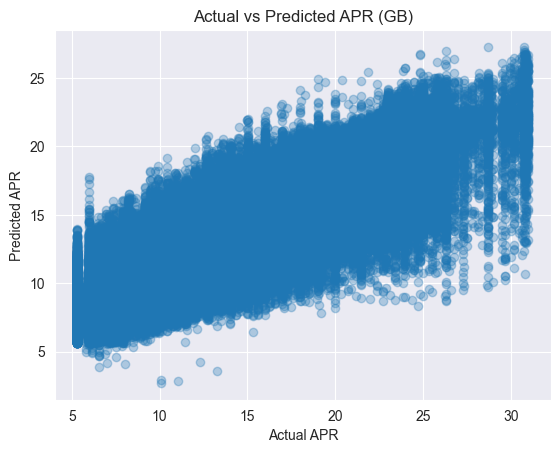

In [26]:
plt.figure()
plt.scatter(y_test_apr, y_pred_gbr, alpha=0.3)
plt.xlabel("Actual APR")
plt.ylabel("Predicted APR")
plt.title("Actual vs Predicted APR (GB)")
plt.savefig("../../output/plots/training/lc/actual_vs_predicted_apr.png")
plt.show()
plt.close()

Quantile Regression (APR Uncertainty)

In [27]:
# Lower bound (10th percentile)
gbr_q10 = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.1,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_q10.fit(X_train_apr, y_train_apr)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'quantile'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft chil

In [28]:
# Median (50th percentile)
gbr_q50 = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.5,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_q50.fit(X_train_apr, y_train_apr)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'quantile'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft chil

In [29]:
# Upper bound (90th percentile)
gbr_q90 = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.9,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_q90.fit(X_train_apr, y_train_apr)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'quantile'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft chil

In [30]:
y_q10 = gbr_q10.predict(X_test_apr)
y_q50 = gbr_q50.predict(X_test_apr)
y_q90 = gbr_q90.predict(X_test_apr)

In [31]:
coverage = ((y_test_apr >= y_q10) & (y_test_apr <= y_q90)).mean()
print("Coverage:", coverage)

Coverage: 0.8082940786743453


In [32]:
interval_width = (y_q90 - y_q10).mean()
print("Avg Interval Width:", interval_width)

Avg Interval Width: 7.594552665434415


In [33]:
y_pred_mean = y_q50.clip(5, 35)
y_pred_low = y_q10.clip(5, 35)
y_pred_high = y_q90.clip(5, 35)

In [34]:
df_apr = pd.DataFrame({
    "actual": y_test_apr,
    "apr_mean": y_pred_mean,
    "apr_low": y_pred_low,
    "apr_high": y_pred_high
})

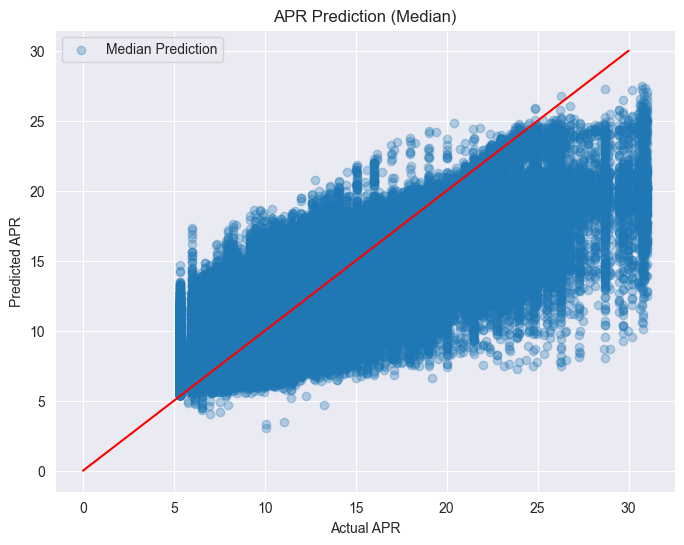

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_apr, y_q50, alpha=0.3, label="Median Prediction")
plt.plot([0,30], [0,30], color='red')

plt.xlabel("Actual APR")
plt.ylabel("Predicted APR")
plt.title("APR Prediction (Median)")
plt.legend()
plt.savefig("../../output/plots/training/lc/apr_prediction.png")
plt.show()
plt.close()

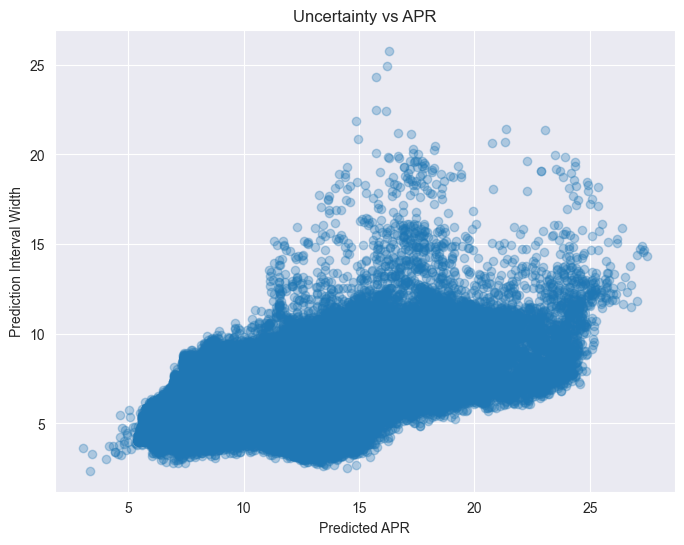

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_q50, y_q90 - y_q10, alpha=0.3)

plt.xlabel("Predicted APR")
plt.ylabel("Prediction Interval Width")
plt.title("Uncertainty vs APR")
plt.savefig("../../output/plots/training/lc/apr_prediction_interval_spread.png")
plt.show()
plt.close()

In [37]:
joblib.dump(gbr, "../../models/apr_model.pkl")

['../../models/apr_model.pkl']

In [38]:
joblib.dump(gbr_q10, "../../models/apr_model_low.pkl")

['../../models/apr_model_low.pkl']

In [39]:
joblib.dump(gbr_q50, "../../models/apr_model_mean.pkl")

['../../models/apr_model_mean.pkl']

In [40]:
joblib.dump(gbr_q90, "../../models/apr_model_high.pkl")

['../../models/apr_model_high.pkl']

In [41]:
with open("../../models/apr_features.json", "w") as f:
    json.dump(features, f)